 ARFF Machine Learning Pipeline


Saving chronic_kidney_disease_full.arff.txt to chronic_kidney_disease_full.arff.txt

 DATASET
Shape: 397 rows × 25 columns
Attributes: age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu, sc, sod, pot, hemo, pcv, wbcc, rbcc, htn, dm, cad, appet, pe, ane, class

 Dataset Preview:
+----+-------+----------+---------+---------+----------+-------+------+-------+------+---------+------+------+---------+---------+--------+---------+----------+---------+-------+------+-------+---------+------+-------+---------+
|    |   age |       bp |      sg |      al |       su |   rbc |   pc |   pcc |   ba |     bgr |   bu |   sc |     sod |     pot |   hemo |     pcv |     wbcc |    rbcc |   htn |   dm |   cad |   appet |   pe |   ane |   class |
+====+=======+==========+=========+=========+==========+=======+======+=======+======+=========+======+======+=========+=========+========+=========+==========+=========+=======+======+=======+=========+======+=======+=========+
|  0 |    48 |  80      | 1.02    | 1 

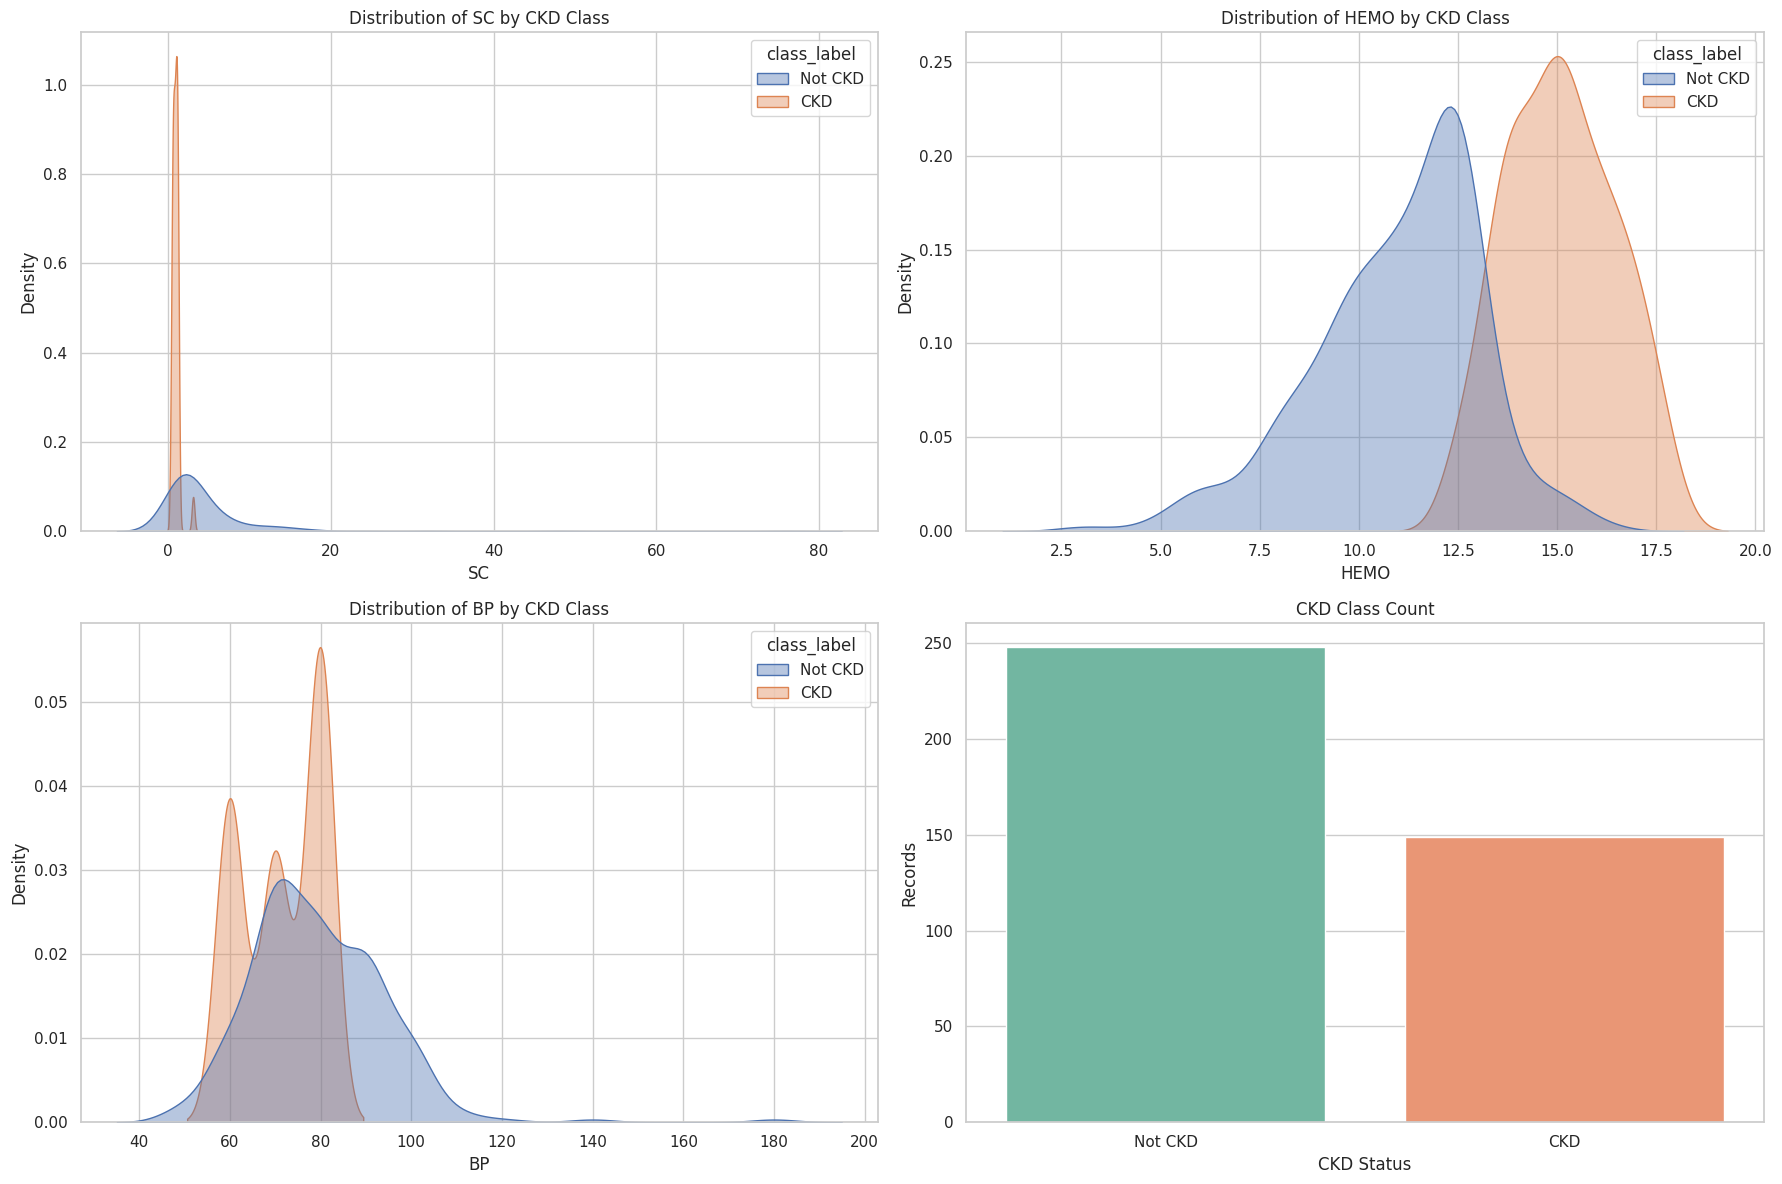

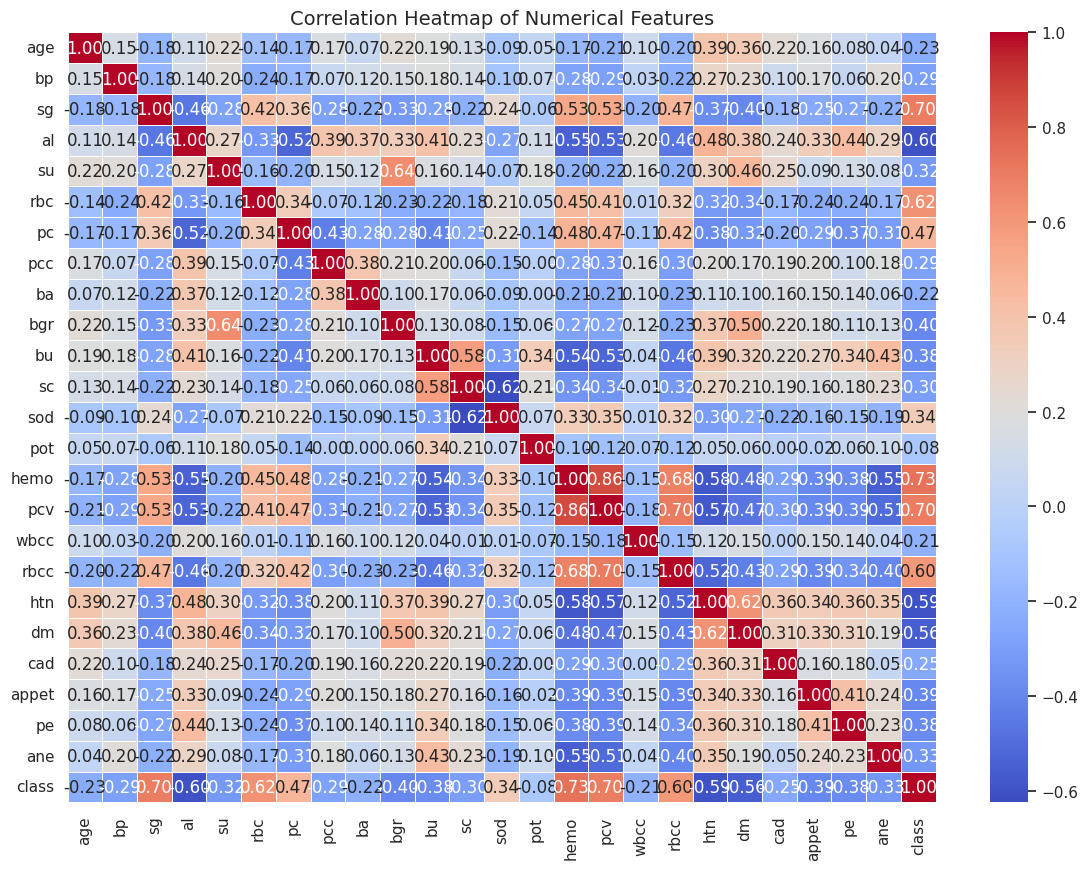


 Model Performance Comparison:
+---------------+------------+-------------+----------+------------+
| Model         |   Accuracy |   Precision |   Recall |   F1-Score |
+===============+============+=============+==========+============+
| Decision Tree |      0.95  |      0.9505 |    0.95  |     0.9496 |
+---------------+------------+-------------+----------+------------+
| Naive Bayes   |      0.975 |      0.975  |    0.975 |     0.975  |
+---------------+------------+-------------+----------+------------+

 Confusion Matrices:

Decision Tree Confusion Matrix:
+----+----+
| 50 |  1 |
+----+----+
|  3 | 26 |
+----+----+

Naive Bayes Confusion Matrix:
+----+----+
| 50 |  1 |
+----+----+
|  1 | 28 |
+----+----+

 Classification Reports:

Decision Tree Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96        51
         1.0       0.96      0.90      0.93        29

    accuracy                           0.95        

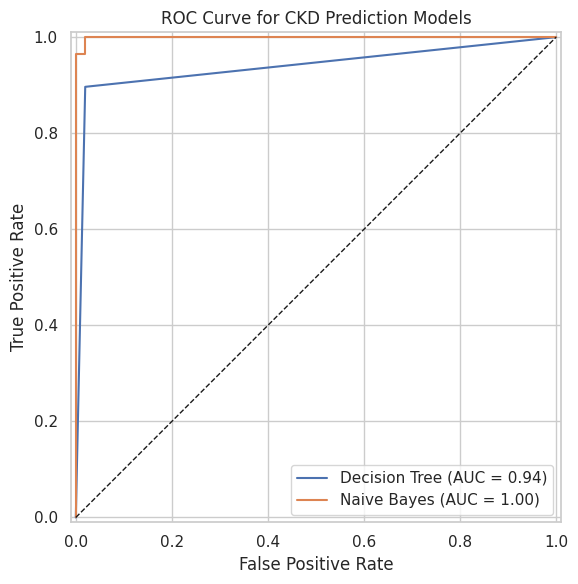


 AUC Scores:
+---------------+-------------+
| Model         |   AUC Score |
+===============+=============+
| Decision Tree |      0.9385 |
+---------------+-------------+
| Naive Bayes   |      0.9993 |
+---------------+-------------+

 Top 10 Feature Importances (Decision Tree):
+--------+-----------+--------------+--------------+
|   Rank | Feature   |   Importance | Percentage   |
+========+===========+==============+==============+
|      1 | hemo      |       0.7217 | 72.17%       |
+--------+-----------+--------------+--------------+
|      2 | sg        |       0.2124 | 21.24%       |
+--------+-----------+--------------+--------------+
|      3 | htn       |       0.0264 | 2.64%        |
+--------+-----------+--------------+--------------+
|      4 | rbcc      |       0.0262 | 2.62%        |
+--------+-----------+--------------+--------------+
|      5 | pot       |       0.0107 | 1.07%        |
+--------+-----------+--------------+--------------+
|      6 | pcv       |     

In [2]:
# Step 1: Install Required Libraries
!pip install scipy pandas scikit-learn tabulate

# Step 2: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from google.colab import files
import io
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

# Step 3: Upload the .arff file
print(" ARFF Machine Learning Pipeline")
print("="*50)
uploaded = files.upload()
filename = list(uploaded.keys())[0]
arff_text = uploaded[filename].decode('utf-8', errors='ignore')

# Step 4: Parse .arff manually
attributes = []
data_section = []
in_data = False

for line in arff_text.splitlines():
    line = line.strip()
    if not line or line.startswith('%'):
        continue
    if line.lower().startswith('@attribute'):
        parts = line.split()
        attr_name = parts[1].strip("'\"")
        attributes.append(attr_name)
    elif line.lower() == '@data':
        in_data = True
    elif in_data:
        values = [val.strip().lower() for val in line.split(',')]
        if len(values) == len(attributes):
            data_section.append(values)


# Step 5: Create DataFrame
df = pd.DataFrame(data_section, columns=attributes)

# Step 6: Clean data
df.columns = df.columns.str.replace("'", "")
df.replace('?', np.nan, inplace=True)

# Try converting columns to numeric
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Impute missing values
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Skip categorical imputation if no such columns
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Display Dataset
print("\n DATASET")
print("="*50)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Attributes: {', '.join(df.columns)}")

print(f"\n Dataset Preview:")
print(tabulate(df.head(15), headers=df.columns, tablefmt="grid", showindex=True))

import matplotlib.pyplot as plt
import seaborn as sns

# Add label column for plots
df['class_label'] = df['class'].map({0: 'Not CKD', 1: 'CKD'})

# Set style
sns.set(style="whitegrid")
features_to_plot = ['sc', 'hemo', 'bp']

plt.figure(figsize=(18, 12))

for i, col in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data=df, x=col, hue='class_label', fill=True, common_norm=False, alpha=0.4)
    plt.title(f'Distribution of {col.upper()} by CKD Class')
    plt.xlabel(col.upper())
    plt.ylabel("Density")

plt.subplot(2, 2, 4)
sns.countplot(data=df, x='class_label', palette='Set2')
plt.title("CKD Class Count")
plt.ylabel("Records")
plt.xlabel("CKD Status")

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

# Step 7: Train/Test Split
X, y = df.drop(['class', 'class_label'], axis=1), df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Train Models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='weighted'),
        "Recall": recall_score(y_test, preds, average='weighted'),
        "F1-Score": f1_score(y_test, preds, average='weighted'),
        "Predictions": preds,
        "Confusion Matrix": confusion_matrix(y_test, preds),
        "Report": classification_report(y_test, preds, zero_division=0),
        "Model": model
    }

# Step 9: Show Metrics
print("\n Model Performance Comparison:")
print("="*50)
print(tabulate(
    [[name] + [f"{results[name][m]:.4f}" for m in ["Accuracy", "Precision", "Recall", "F1-Score"]] for name in results],
    headers=["Model", "Accuracy", "Precision", "Recall", "F1-Score"],
    tablefmt="grid"
))

# Step 10: Confusion Matrices
print("\n Confusion Matrices:")
print("="*50)
for name in results:
    print(f"\n{name} Confusion Matrix:")
    print(tabulate(results[name]["Confusion Matrix"], tablefmt="grid"))

# Step 11: Classification Reports
print("\n Classification Reports:")
print("="*50)
for name in results:
    print(f"\n{name} Classification Report:\n{results[name]['Report']}")

from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Step 13: ROC Curve and AUC
print("\n ROC Curve and AUC Scores")
print("="*60)

plt.figure(figsize=(10, 6))

for name in results:
    model = results[name]['Model']

    # If model doesn't have predict_proba, use decision_function or skip
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        print(f"{name} does not support predict_proba, skipping ROC.")
        continue

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = auc(fpr, tpr)
    results[name]['AUC'] = auc_score

    # Plot
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name=name).plot(ax=plt.gca())

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curve for CKD Prediction Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Display AUC Scores
print("\n AUC Scores:")
print("="*50)
auc_table = [[name, f"{results[name].get('AUC', 'N/A'):.4f}"] for name in results if 'AUC' in results[name]]
print(tabulate(auc_table, headers=["Model", "AUC Score"], tablefmt="grid"))


# Step 12: Feature Importance (Decision Tree)
dt_model = results["Decision Tree"]["Model"]
if hasattr(dt_model, 'feature_importances_'):
    print("\n Top 10 Feature Importances (Decision Tree):")
    print("="*50)
    fi = dt_model.feature_importances_
    top_features = sorted(zip(X.columns, fi), key=lambda x: x[1], reverse=True)[:10]
    print(tabulate(
        [[i+1, f, f"{imp:.4f}", f"{imp*100:.2f}%"] for i, (f, imp) in enumerate(top_features)],
        headers=["Rank", "Feature", "Importance", "Percentage"], tablefmt="grid"
    ))

# Step 13: Best Model
best = max(results.items(), key=lambda x: x[1]["Accuracy"])
print(f"\n Best Model: {best[0]} with Accuracy {best[1]['Accuracy']*100:.2f}%")
print("="*50)

# Step 14: Summary
print(f"\n Summary Statistics:")
print("="*50)
print(f"Total samples: {len(df)}")
print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")
print(f"Number of features: {X.shape[1]}")
print(f"Class distribution: {dict(df['class'].value_counts())}")

# Display individual model accuracies
print(f"\n Individual Model Accuracies:")
print("="*50)
for name, result in results.items():
    print(f"{name}: {result['Accuracy']*100:.2f}%")

print("\n Project Complete!")
print("="*50)